# Cornerstone fine-tune — training run comparison

Visual comparison of the `cornerstone_finetune` runs logged under `runs/cornerstone/`
(TensorBoard event files + `hparams.yaml`). Data loaded directly from the event files —
no manual copying.

| run | model init | channels | loss |
|-----|-----------|----------|------|
| `core6` | internal BTCV ckpt (`epoch=483-val_loss=0.07`) | 6ch (liver, portal_tree, ivc, aorta, gallbladder, vessels) | Dice + BCE + clDice |
| `core6_tversky` | internal BTCV ckpt | 6ch | **Tversky**(α=0.3, β=0.7) + BCE + clDice |
| `core5` | internal BTCV ckpt | 5ch (no gallbladder) | Dice + BCE + clDice |
| `core5_paper_backbone` | paper benchmark backbone (`swin_unetr.pth`) | 5ch | Dice + BCE + clDice |
| `core5_paper_cldice` | paper benchmark backbone | 5ch | Dice + BCE + clDice (**λ_clDice 0.5→0.8**) |

Monitor metric: `val/dice_thin` = mean Dice over the thin channels (portal_tree, ivc, vessels).
Beware `val/dice`: it is the plain mean over all channels and is dominated by liver.


In [4]:
from __future__ import annotations

import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml
from IPython.display import display
from tensorboard.backend.event_processing import event_accumulator

%matplotlib inline

plt.rcParams.update({
    "figure.dpi": 100,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "legend.framealpha": 0.6,
    "font.size": 10,
})

RUNS_ROOT = Path("runs/cornerstone")

RUNS = {
    "core6":                {"label": "core6 (int. backbone)",        "color": "tab:gray"},
    "core6_tversky":        {"label": "core6_tversky (Tversky)",      "color": "tab:purple"},
    "core5":                {"label": "core5 (int. backbone)",        "color": "tab:blue"},
    "core5_paper_backbone": {"label": "core5_paper (paper backbone)", "color": "tab:green"},
    "core5_paper_cldice":   {"label": "core5_paper_clDice (λ=0.8)",   "color": "tab:red"},
}

# union channel order (core5 family has no gallbladder)
CHANNELS = ["liver", "portal_tree", "ivc", "aorta", "gallbladder", "vessels"]

print("runs:", sorted(p.name for p in RUNS_ROOT.glob("*") if p.is_dir()))


runs: ['core5', 'core5_paper_backbone', 'core5_paper_cldice', 'core6', 'core6_tversky']


In [5]:
def load_events(run: str):
    """Merge all TensorBoard event files of a run (resumes live in separate
    version_*/files; test metrics in yet another file). Returns
    (val_tags: {tag: {step: value}}, test_tags, step->epoch map)."""
    val, test, epoch_map = {}, {}, {}
    for path in sorted((RUNS_ROOT / run / "tb").glob("version_*/events*")):
        ea = event_accumulator.EventAccumulator(str(path), size_guidance={"scalars": 0})
        ea.Reload()
        for tag in ea.Tags()["scalars"]:
            for s in ea.Scalars(tag):
                if tag == "epoch":
                    epoch_map[s.step] = s.value
                elif tag.startswith("test/"):
                    test.setdefault(tag, {})[s.step] = s.value
                elif tag.startswith("val/") or tag == "train/loss_epoch":
                    val.setdefault(tag, {})[s.step] = s.value
    return val, test, epoch_map


def run_curve(run: str) -> pd.DataFrame:
    """Validation metrics per epoch, indexed by epoch."""
    val, _, epoch_map = load_events(run)
    df = pd.DataFrame({tag: pd.Series(d) for tag, d in val.items()})
    df.index.name = "step"
    ep = pd.Series(epoch_map).sort_index()
    # epoch recorded at step s = epoch whose validation just finished there
    df["epoch"] = [ep.loc[:s].iloc[-1] if (ep.index <= s).any() else np.nan
                   for s in df.index]
    df = (df.dropna(subset=["epoch"])
            .set_index("epoch")
            .sort_index())
    df = df[~df.index.duplicated(keep="last")]
    df.index = df.index.astype(int)
    return df


curves = {run: run_curve(run) for run in RUNS}
tests = {}
for run in RUNS:
    _, t, _ = load_events(run)
    tests[run] = {tag: pd.Series(d) for tag, d in t.items()}

print("epoch range per run:",
      {r: (int(df.index.min()), int(df.index.max())) for r, df in curves.items()})
print("test metrics available:", {r: bool(t) for r, t in tests.items()})


epoch range per run: {'core6': (0, 297), 'core6_tversky': (0, 117), 'core5': (0, 299), 'core5_paper_backbone': (0, 299), 'core5_paper_cldice': (0, 299)}
test metrics available: {'core6': False, 'core6_tversky': True, 'core5': True, 'core5_paper_backbone': True, 'core5_paper_cldice': True}


In [6]:
def hparams(run: str) -> dict:
    files = sorted((RUNS_ROOT / run / "tb").glob("version_*/hparams.yaml"))
    return yaml.safe_load(open(files[0]))


def short_pretrained(path: str) -> str:
    name = Path(path).name
    return "internal ckpt" if "epoch=" in name else "paper pth"


rows = []
for run in RUNS:
    h = hparams(run)
    rows.append({
        "run": run,
        "channels": len(h["channel_names"]),
        "thin": h["thin_channels"],
        "pretrained": short_pretrained(h["pretrained_weights"]),
        "lambda_dice": h["lambda_dice"],
        "lambda_bce": h["lambda_bce"],
        "lambda_cldice": h["lambda_cldice"],
        "tversky": f'{h["tversky_alpha"]}/{h["tversky_beta"]}' if h.get("use_tversky") else "-",
        "lr": h["learning_rate"],
        "enc_lr_scale": h["encoder_lr_scale"],
        "freeze_ep": h.get("freeze_encoder_epochs", 0),
        "monitor": h.get("monitor", "val/dice_thin"),
    })

hp = pd.DataFrame(rows).set_index("run")
display(hp)


,channels,thin,pretrained,lambda_dice,lambda_bce,lambda_cldice,tversky,lr,enc_lr_scale,freeze_ep,monitor
run,,,,,,,,,,,
core6,6,"[1, 2, 5]",internal ckpt,1.0,1.0,0.5,-,0.0003,0.3,0,val/dice_thin
core6_tversky,6,"[1, 2, 5]",internal ckpt,1.0,1.0,0.5,0.3/0.7,0.0003,0.3,0,val/dice_thin
core5,5,"[1, 2, 4]",internal ckpt,1.0,1.0,0.5,-,0.0003,0.3,0,val/dice_thin
core5_paper_backbone,5,"[1, 2, 4]",paper pth,1.0,1.0,0.5,-,0.0003,0.3,0,val/dice_thin
core5_paper_cldice,5,"[1, 2, 4]",paper pth,1.0,1.0,0.8,-,0.0003,0.3,0,val/dice_thin


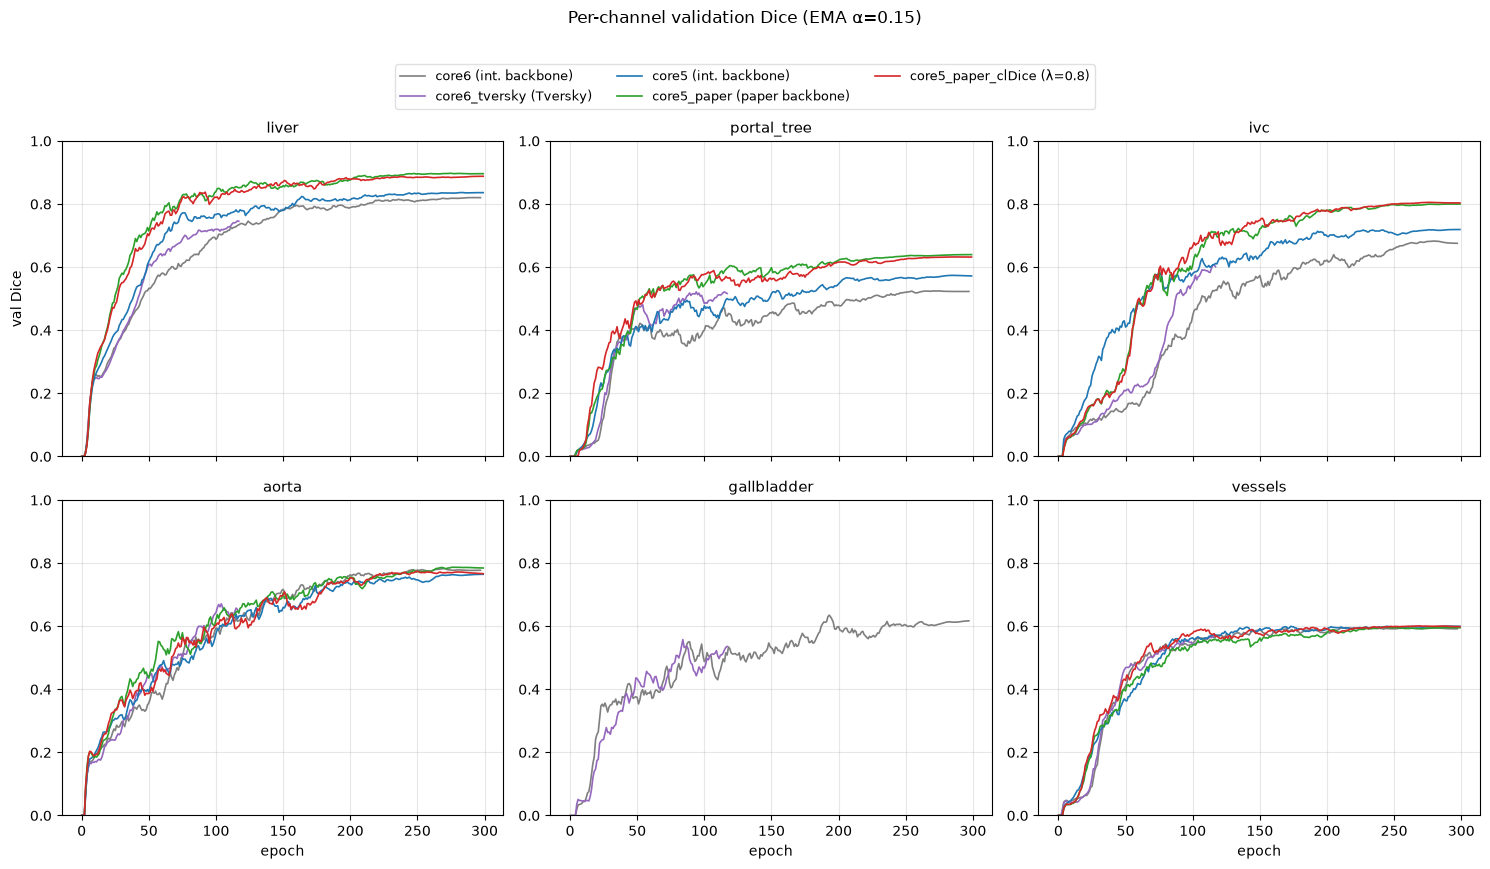

In [7]:
def ema(s: pd.Series, alpha: float = 0.15) -> pd.Series:
    return s.astype(float).ewm(alpha=alpha, min_periods=1).mean()


fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True)
for ax, ch in zip(axes.ravel(), CHANNELS):
    tag = f"val/dice_{ch}"
    for run, info in RUNS.items():
        df = curves[run]
        if tag not in df:
            continue
        s = ema(df[tag].interpolate(limit=2))
        ax.plot(s.index, s, color=info["color"], label=info["label"], lw=1.2)
    ax.set_title(ch, fontsize=11)
    ax.set_ylim(0, 1)
axes[0, 0].set_ylabel("val Dice")
for ax in axes[-1]:
    ax.set_xlabel("epoch")
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, bbox_to_anchor=(0.5, 1.02), fontsize=9)
fig.suptitle("Per-channel validation Dice (EMA α=0.15)", y=1.08)
fig.tight_layout()
plt.show()


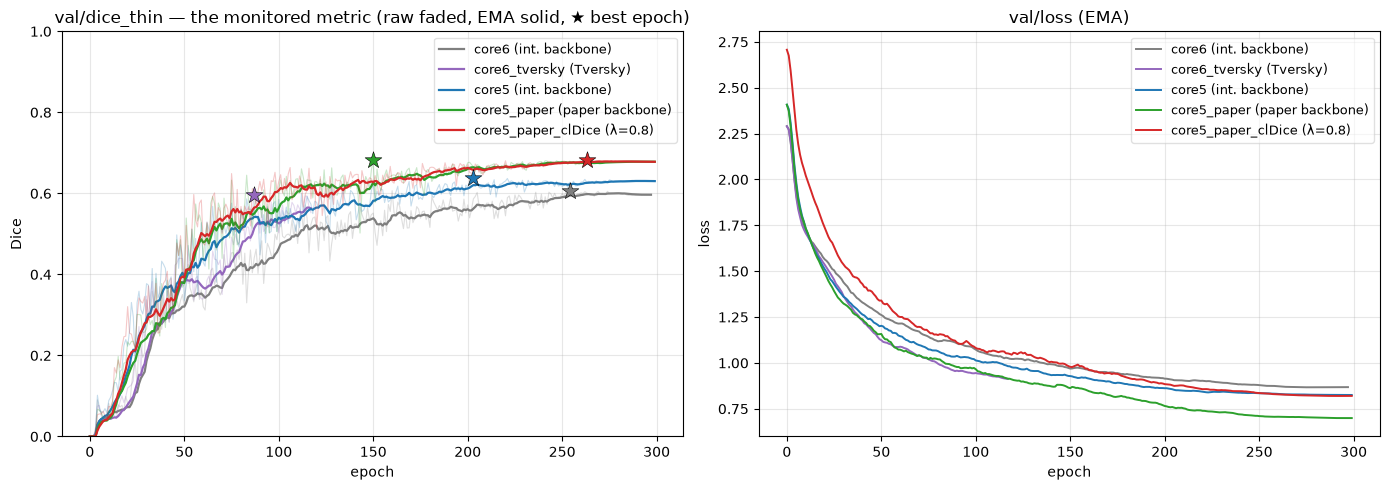

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for run, info in RUNS.items():
    raw = curves[run]["val/dice_thin"].interpolate(limit=2)
    ax.plot(raw.index, raw, color=info["color"], alpha=0.25, lw=0.8)
    ax.plot(raw.index, ema(raw), color=info["color"], lw=1.6, label=info["label"])
    best = raw.idxmax()
    ax.scatter(best, raw.loc[best], color=info["color"], marker="*", s=160, zorder=5,
               edgecolors="k", linewidths=0.4)
ax.set_title("val/dice_thin — the monitored metric (raw faded, EMA solid, ★ best epoch)")
ax.set_ylabel("Dice"); ax.set_xlabel("epoch"); ax.set_ylim(0, 1)
ax.legend(fontsize=9)

ax = axes[1]
for run, info in RUNS.items():
    s = ema(curves[run]["val/loss"].interpolate(limit=2))
    ax.plot(s.index, s, color=info["color"], lw=1.4, label=info["label"])
ax.set_title("val/loss (EMA)")
ax.set_xlabel("epoch"); ax.set_ylabel("loss")
ax.legend(fontsize=9)

fig.tight_layout()
plt.show()


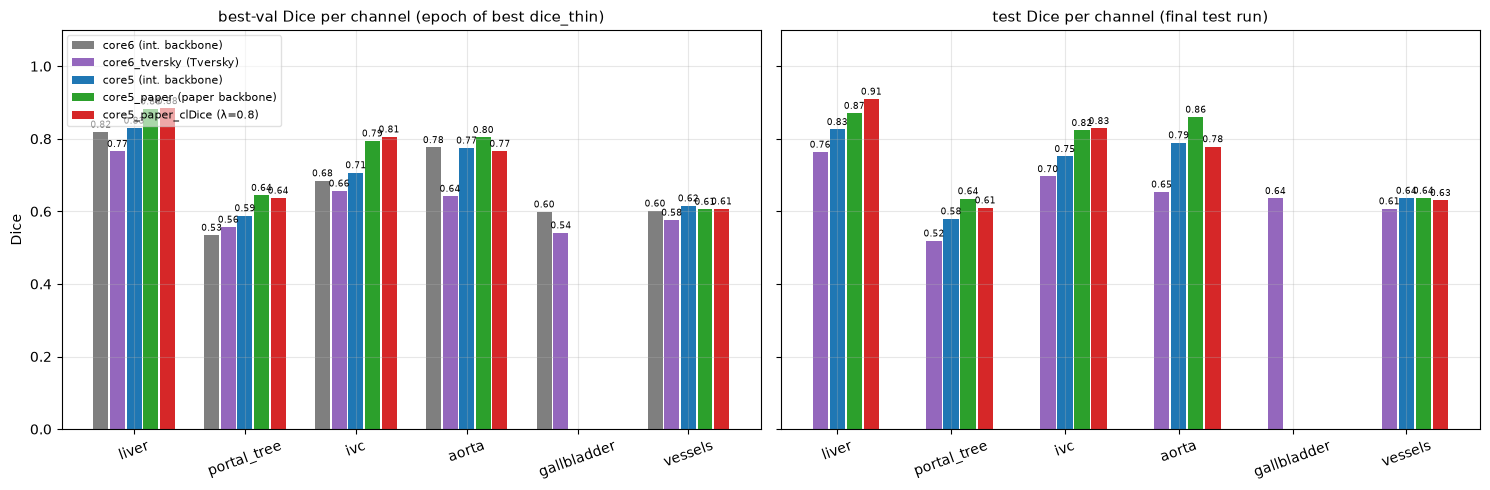

In [9]:
def best_epoch_metrics(run: str) -> pd.Series:
    """Val metrics at the epoch of best val/dice_thin."""
    df = curves[run]
    return df.loc[df["val/dice_thin"].idxmax()]


val_summary = pd.DataFrame({
    run: best_epoch_metrics(run).rename(lambda c: c.replace("val/dice_", ""))
    for run in RUNS
}).T

test_summary = pd.DataFrame({
    run: {tag.replace("test/dice_", ""): v.iloc[-1]
          for tag, v in t.items() if tag.startswith("test/dice_")}
    for run, t in tests.items()
}).T

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
x = np.arange(len(CHANNELS))
width = 0.15
for k, (ax, summary, title) in enumerate(zip(
        axes,
        [val_summary, test_summary],
        ["best-val Dice per channel (epoch of best dice_thin)",
         "test Dice per channel (final test run)"])):
    for j, run in enumerate(RUNS):
        vals = [summary.loc[run, ch] if ch in summary.columns else np.nan for ch in CHANNELS]
        offs = (j - (len(RUNS) - 1) / 2) * width
        ax.bar(x + offs, vals, width * 0.9, label=RUNS[run]["label"], color=RUNS[run]["color"])
        for xi, v in zip(x, vals):
            if np.isfinite(v):
                ax.text(xi + offs, min(v, 1) + 0.012, f"{v:.2f}", ha="center", fontsize=6.5)
    ax.set_xticks(x)
    ax.set_xticklabels(CHANNELS, rotation=20)
    ax.set_ylim(0, 1.10)
    ax.set_title(title, fontsize=11)
axes[0].set_ylabel("Dice")
axes[0].legend(fontsize=8, loc="upper left")
fig.tight_layout()
plt.show()


In [10]:
summary = []
for run in RUNS:
    df = curves[run]
    raw = df["val/dice_thin"].interpolate(limit=2)
    i = raw.idxmax()
    t = tests[run]
    summary.append({
        "run": run,
        "epochs_run": len(df),
        "best val/dice_thin": raw.loc[i],
        "@ epoch": i,
        "val/dice (mean) @best": df.loc[i, "val/dice"],
        "test/dice_thin": t["test/dice_thin"].iloc[-1] if "test/dice_thin" in t else np.nan,
        "test/dice (mean)": t["test/dice"].iloc[-1] if "test/dice" in t else np.nan,
        "test/dice_bulk": t["test/dice_bulk"].iloc[-1] if "test/dice_bulk" in t else np.nan,
    })
display(pd.DataFrame(summary).set_index("run").round(4))


,epochs_run,best val/dice_thin,@ epoch,val/dice (mean) @best,test/dice_thin,test/dice (mean),test/dice_bulk
run,,,,,,,
core6,298,0.6068,254,0.6691,NaN,NaN,NaN
core6_tversky,118,0.5965,87,0.6230,0.6074,0.6459,0.6843
core5,300,0.6369,203,0.7031,0.6559,0.7166,0.8076
core5_paper_backbone,300,0.6816,150,0.7463,0.6984,0.7651,0.8652
core5_paper_cldice,300,0.6832,263,0.7398,0.6896,0.7514,0.8441


In [11]:
print("best checkpoints (per-run, by value in monitor filename):")
for run in RUNS:
    ckpts = list((RUNS_ROOT / run / "checkpoints").glob("epoch*-val_dice_thin*.ckpt"))
    best = max(ckpts, key=lambda p: float(re.search(r"(\d\.\d+)\.ckpt$", p.name).group(1))) if ckpts else None
    print(f"  {run:24s} {best.name if best else '(none)'}")


best checkpoints (per-run, by value in monitor filename):
  core6                    epoch254-val_dice_thin0.6068.ckpt
  core6_tversky            epoch087-val_dice_thin0.5965.ckpt
  core5                    epoch203-val_dice_thin0.6369.ckpt
  core5_paper_backbone     epoch150-val_dice_thin0.6816.ckpt
  core5_paper_cldice       epoch263-val_dice_thin0.6832.ckpt


## Takeaways

- **Paper backbone wins on the bulk channels** (liver / portal_tree / ivc / aorta) but the thin
  `vessels` channel stays ~0.59-0.60 regardless of init.
- **λ_clDice 0.8** (`core5_paper_cldice`) slightly beats λ=0.5 on `portal_tree` and thin mean;
  best `val/dice_thin` reaches ~0.683 vs 0.682.
- **Tversky β>α** (`core6_tversky`) did not recover distal recall — plateau lower than core6
  (stopped early).
- **6 channels** (`core6`) slightly dilute the thin channels vs the 5-channel `core5`.
- All runs plateau on `val/dice_thin` long before epoch 300 while the cosine LR decays to zero —
  i.e. further epochs buy nothing; see `training_diary.md` for the "raise once dice_thin plateaus" knob.
